# Resale Listing Tables — Exploratory Data Analysis

Data source: `RESALE_LISTING_TABLES.xlsx`  
Tables: `LISTINGS`, `LISTING_ITEMS`, `LISTING_ACTIVITIES`, `LISTING_ACTIVITY_ITEMS`, `EVENTS`, `CLIENT_GROUPS`

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

FILE = 'RESALE_LISTING_TABLES.xlsx'

listings      = pd.read_excel(FILE, sheet_name='LISTINGS')
items         = pd.read_excel(FILE, sheet_name='LISTING_ITEMS')
activities    = pd.read_excel(FILE, sheet_name='LISTING_ACTIVITIES')
act_items     = pd.read_excel(FILE, sheet_name='LISTING_ACTIVITY_ITEMS')
events        = pd.read_excel(FILE, sheet_name='EVENTS')
groups        = pd.read_excel(FILE, sheet_name='CLIENT_GROUPS')

print('Loaded sheets:')
for name, df in [('LISTINGS', listings), ('LISTING_ITEMS', items),
                 ('LISTING_ACTIVITIES', activities), ('LISTING_ACTIVITY_ITEMS', act_items),
                 ('EVENTS', events), ('CLIENT_GROUPS', groups)]:
    print(f'  {name}: {df.shape[0]:,} rows × {df.shape[1]} cols')

Loaded sheets:
  LISTINGS: 12,018 rows × 17 cols
  LISTING_ITEMS: 21,622 rows × 21 cols
  LISTING_ACTIVITIES: 23,899 rows × 15 cols
  LISTING_ACTIVITY_ITEMS: 37,388 rows × 7 cols
  EVENTS: 617 rows × 139 cols
  CLIENT_GROUPS: 116 rows × 108 cols


---
## 1. Schema Overview

In [50]:
for name, df in [('LISTINGS', listings), ('LISTING_ITEMS', items),
                 ('LISTING_ACTIVITIES', activities), ('EVENTS', events)]:
    print(f'\n=== {name} ===')
    print(df.dtypes.to_string())


=== LISTINGS ===
ID                                   int64
OPTLOCK                              int64
LISTING_ID                          object
SELLER_USER_ID                       int64
SELLER_ORDER_ID                     object
ORIGIN_ORDER_ID                     object
GROUP_ID                             int64
EVENT_ID                             int64
SALE_ID                              int64
TIER_ID                              int64
CURRENCY                            object
DELIVERY_TYPE                       object
ADDITIONAL_DELIVERY_TYPE            object
ALLOW_SPLIT                          int64
DO_NOT_LEAVE_SINGLE                  int64
CREATE_DATE                 datetime64[ns]
LMD_DATE                    datetime64[ns]

=== LISTING_ITEMS ===
                                                          int64
LISTING_ID                                                int64
LISTING_ITEM_ID                                          object
SELLER_SALE_ORDER_ITEM_ID           

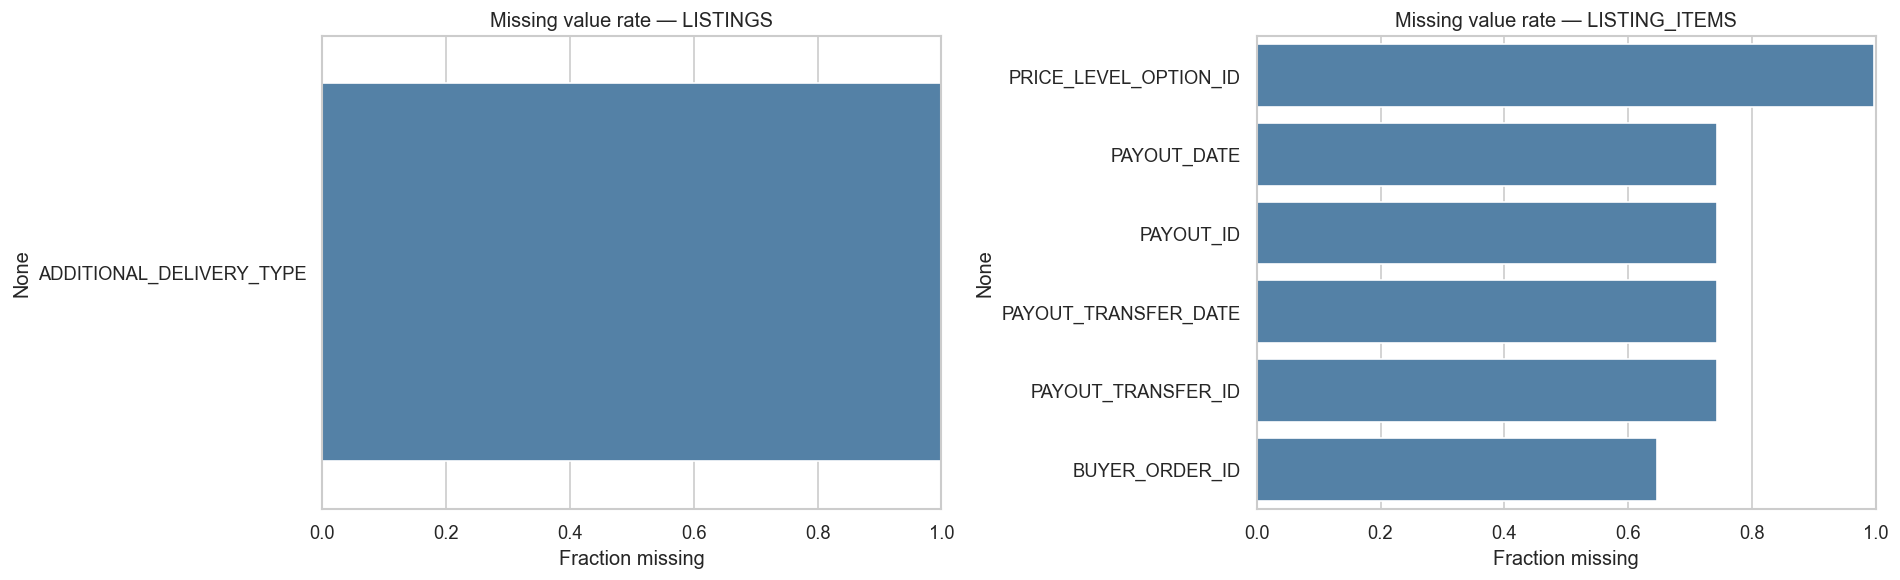

In [45]:
# Missing value heatmap for key tables
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (name, df) in zip(axes, [('LISTINGS', listings), ('LISTING_ITEMS', items)]):
    miss = df.isnull().mean().sort_values(ascending=False)
    miss = miss[miss > 0]
    sns.barplot(x=miss.values, y=miss.index, ax=ax, color='steelblue')
    ax.set_title(f'Missing value rate — {name}')
    ax.set_xlabel('Fraction missing')
    ax.set_xlim(0, 1)

plt.tight_layout()
plt.show()

---
## 2. Listings Overview

In [27]:
print('=== LISTINGS basic stats ===')
print(f"Unique listing IDs : {listings['LISTING_ID'].nunique():,}")
print(f"Unique sellers     : {listings['SELLER_USER_ID'].nunique():,}")
print(f"Unique events      : {listings['EVENT_ID'].nunique():,}")
print(f"Currencies         : {listings['CURRENCY'].unique()}")
print(f"Delivery types     : {listings['DELIVERY_TYPE'].value_counts().to_dict()}")
print(f"Date range         : {listings['CREATE_DATE'].min().date()} → {listings['CREATE_DATE'].max().date()}")

=== LISTINGS basic stats ===
Unique listing IDs : 12,018
Unique sellers     : 7,321
Unique events      : 617
Currencies         : ['USD' 'CAD']
Delivery types     : {'ELECTRONIC': 9972, 'SHIPPING': 1961, 'WILLCALL': 80, 'NONE': 5}
Date range         : 2025-03-27 → 2026-04-01


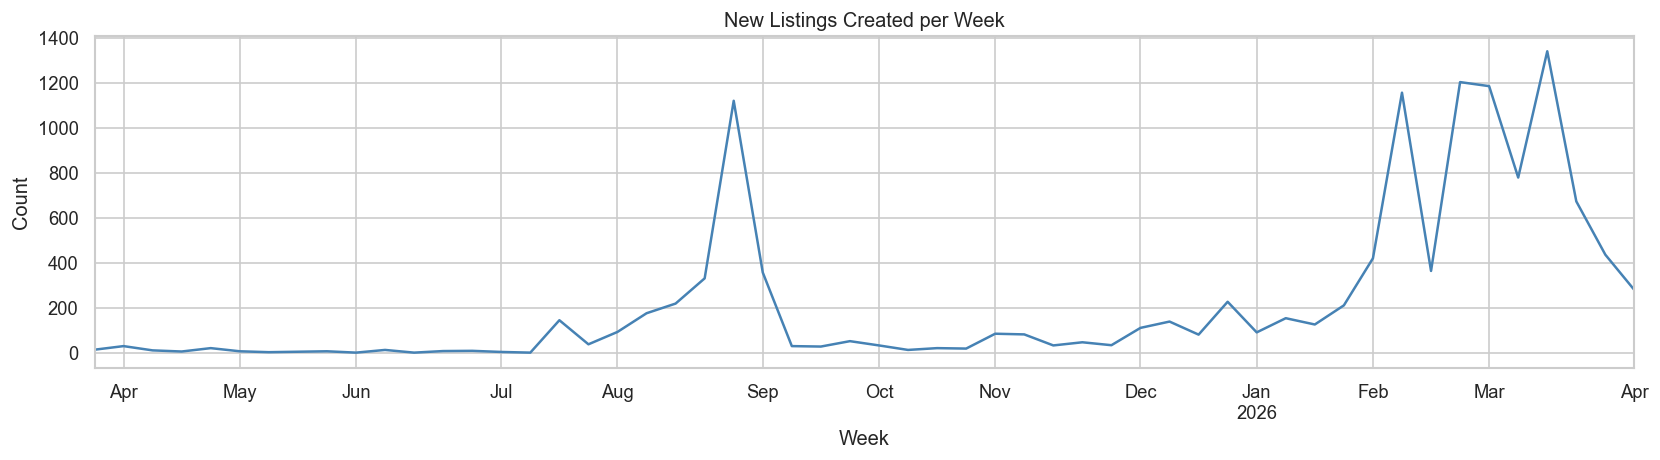

In [28]:
# Listings created over time (weekly)
listings['CREATE_DATE'] = pd.to_datetime(listings['CREATE_DATE'])
weekly = listings.set_index('CREATE_DATE').resample('W').size()

fig, ax = plt.subplots(figsize=(14, 4))
weekly.plot(ax=ax, color='steelblue')
ax.set_title('New Listings Created per Week')
ax.set_xlabel('Week')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

/var/folders/hv/7x8xz7md273b03pflknc6k900000gn/T/ipykernel_80754/2586446309.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_events, x='listing_count', y='NAME', ax=ax, palette='Blues_r')


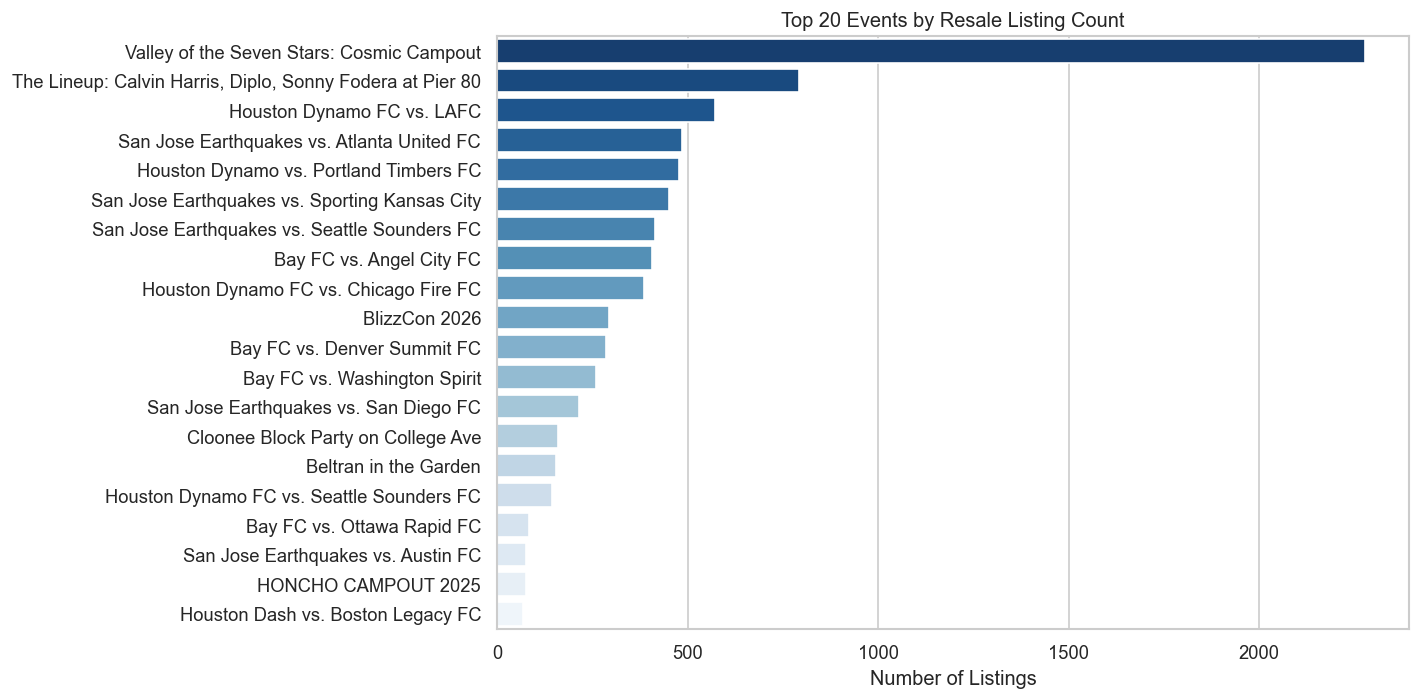

In [29]:
# Top 20 events by listing count
top_events = (
    listings.groupby('EVENT_ID').size()
    .sort_values(ascending=False)
    .head(20)
    .reset_index(name='listing_count')
    .merge(events[['ID', 'NAME']], left_on='EVENT_ID', right_on='ID', how='left')
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=top_events, x='listing_count', y='NAME', ax=ax, palette='Blues_r')
ax.set_title('Top 20 Events by Resale Listing Count')
ax.set_xlabel('Number of Listings')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

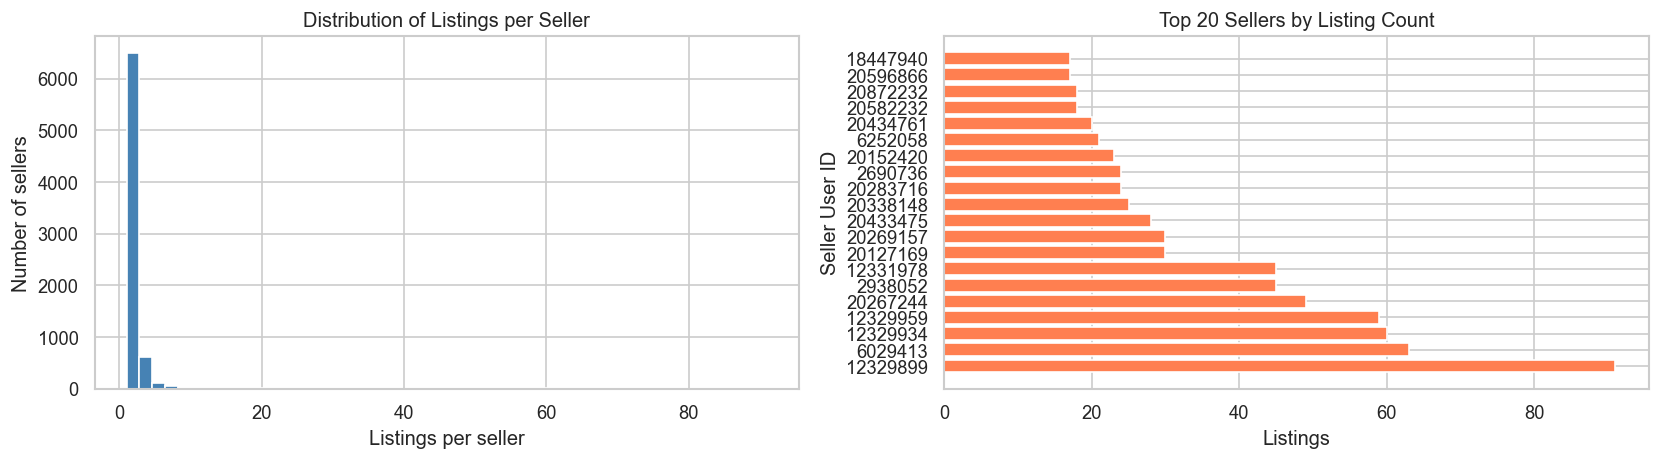

In [30]:
# Listings per seller distribution
seller_counts = listings.groupby('SELLER_USER_ID').size()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(seller_counts, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Listings per Seller')
axes[0].set_xlabel('Listings per seller')
axes[0].set_ylabel('Number of sellers')

top_sellers = seller_counts.sort_values(ascending=False).head(20)
axes[1].barh(top_sellers.index.astype(str), top_sellers.values, color='coral')
axes[1].set_title('Top 20 Sellers by Listing Count')
axes[1].set_xlabel('Listings')
axes[1].set_ylabel('Seller User ID')

plt.tight_layout()
plt.show()

---
## 3. Listing Items — Pricing Analysis

In [31]:
print('=== LISTING_ITEMS status breakdown ===')
display(items['STATUS'].value_counts().rename('count').to_frame())

print('\n=== Payout status breakdown ===')
display(items['PAYOUT_STATUS'].value_counts().rename('count').to_frame())

=== LISTING_ITEMS status breakdown ===


,count
STATUS,
SOLD,10950
ACTIVE,6061
ARCHIVED,4611



=== Payout status breakdown ===


,count
PAYOUT_STATUS,
NOT_INITIATED,15979
PAID,5516
NOT_PAYABLE,83
PENDING,27
FAILED,17


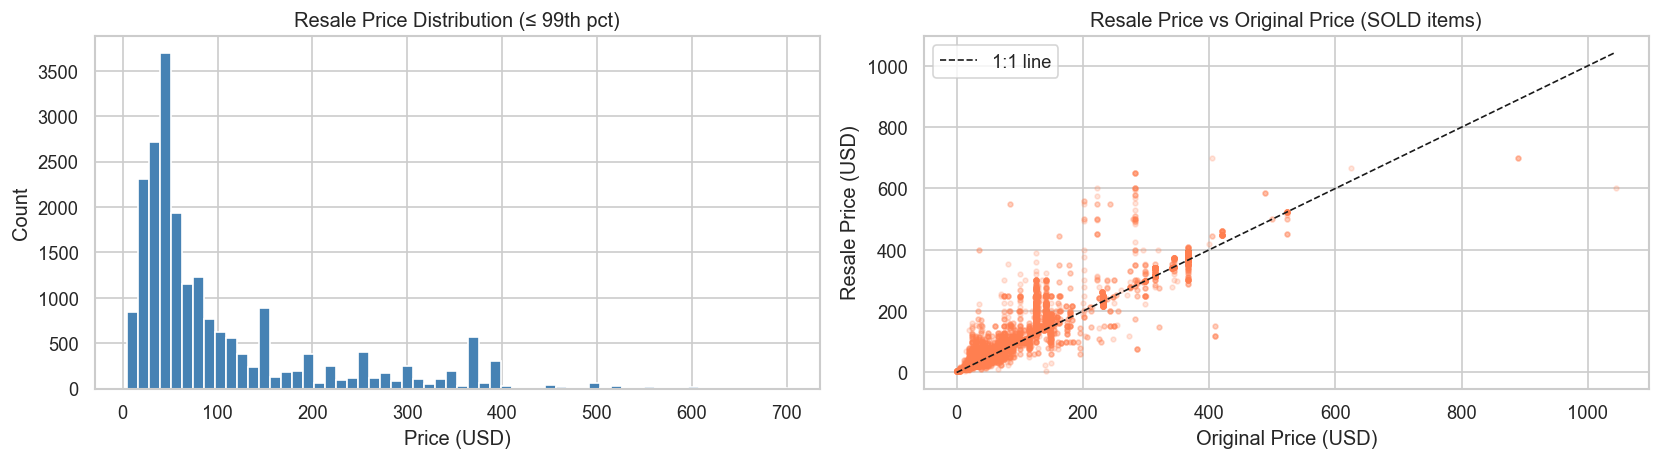

In [32]:
# Price distribution (cap at 99th percentile to reduce skew)
price_col = items['PRICE'].dropna()
p99 = price_col.quantile(0.99)
price_trim = price_col[price_col <= p99]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(price_trim, bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Resale Price Distribution (≤ 99th pct)')
axes[0].set_xlabel('Price (USD)')
axes[0].set_ylabel('Count')

# Price vs original price scatter (sold only)
sold = items[items['STATUS'] == 'SOLD'].copy()
sold_trim = sold[(sold['PRICE'] <= p99) & (sold['SELLER_SALE_ORDER_ITEM_ORIGINAL_DISPLAY_PRICE'] > 0)]
axes[1].scatter(
    sold_trim['SELLER_SALE_ORDER_ITEM_ORIGINAL_DISPLAY_PRICE'],
    sold_trim['PRICE'],
    alpha=0.2, s=8, color='coral'
)
lim = max(sold_trim['PRICE'].max(), sold_trim['SELLER_SALE_ORDER_ITEM_ORIGINAL_DISPLAY_PRICE'].max())
axes[1].plot([0, lim], [0, lim], 'k--', linewidth=1, label='1:1 line')
axes[1].set_title('Resale Price vs Original Price (SOLD items)')
axes[1].set_xlabel('Original Price (USD)')
axes[1].set_ylabel('Resale Price (USD)')
axes[1].legend()

plt.tight_layout()
plt.show()

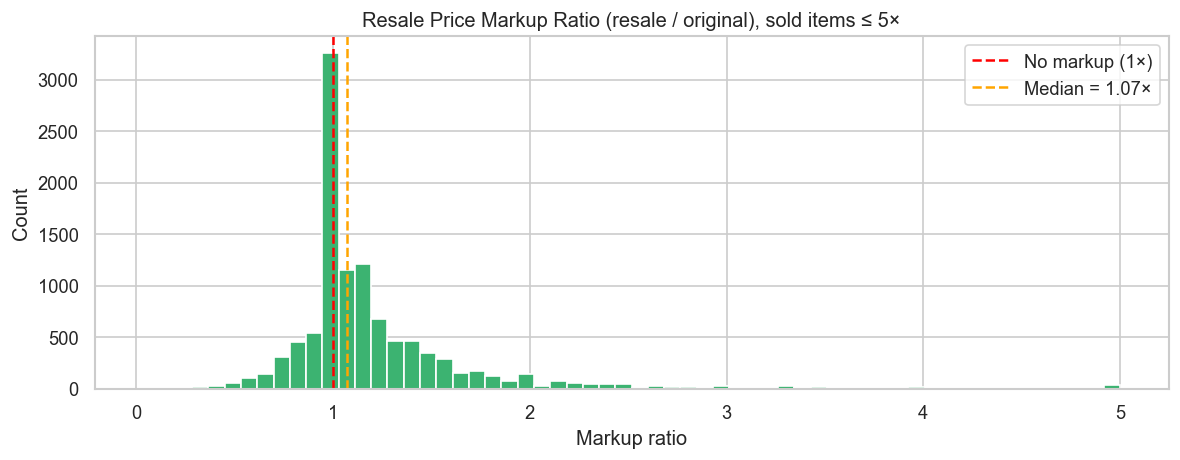

count    10654.000
mean         1.222
std          0.634
min          0.035
25%          1.000
50%          1.071
75%          1.284
max         12.000
Name: markup_ratio, dtype: float64


In [33]:
# Markup ratio: resale price / original price
sold_markup = sold_trim.copy()
sold_markup['markup_ratio'] = sold_markup['PRICE'] / sold_markup['SELLER_SALE_ORDER_ITEM_ORIGINAL_DISPLAY_PRICE']
markup_trim = sold_markup['markup_ratio'][sold_markup['markup_ratio'] <= 5]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(markup_trim, bins=60, color='mediumseagreen', edgecolor='white')
ax.axvline(1.0, color='red', linestyle='--', label='No markup (1×)')
ax.axvline(markup_trim.median(), color='orange', linestyle='--',
           label=f'Median = {markup_trim.median():.2f}×')
ax.set_title('Resale Price Markup Ratio (resale / original), sold items ≤ 5×')
ax.set_xlabel('Markup ratio')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

print(sold_markup['markup_ratio'].describe().round(3))

In [51]:
# Fee breakdown for sold items
sold_fees = sold[['PRICE', 'TIXR_FEE', 'PAYOUT_AMOUNT']].dropna()

print('=== Fee summary for SOLD items (USD) ===')
display(sold_fees.describe().round(2))

sold_fees['fee_pct'] = sold_fees['TIXR_FEE'] / sold_fees['PRICE'] * 100
print(f"\nAverage Tixr fee as % of resale price: {sold_fees['fee_pct'].median():.1f}% (median)")

=== Fee summary for SOLD items (USD) ===


,PRICE,TIXR_FEE,PAYOUT_AMOUNT
count,10950.00,10950.00,10950.00
mean,136.09,6.45,129.47
std,234.42,9.78,232.26
min,5.00,0.00,3.23
25%,40.00,1.21,36.00
50%,60.00,4.00,54.01
75%,150.00,7.45,147.52
max,4103.71,319.90,4103.71



Average Tixr fee as % of resale price: 10.0% (median)


---
## 4. Listing Activities — Conversion Funnel

In [35]:
print('=== Activity type distribution ===')
display(activities['TYPE'].value_counts().rename('count').to_frame())

=== Activity type distribution ===


,count
TYPE,
SOLD,7768
PRICE_CHANGE,5661
TRANSFER,4276
PAID,3573
ARCHIVE,2595
PAYOUT_FAILED,26


In [36]:
# Conversion rate: what fraction of listings resulted in a SOLD activity?
sold_listing_ids = activities[activities['TYPE'] == 'SOLD']['LISTING_ID'].dropna().unique()
total_listings = listings['ID'].nunique()
conversion_rate = len(sold_listing_ids) / total_listings

print(f'Total listing IDs (LISTINGS table) : {total_listings:,}')
print(f'Listings with ≥1 SOLD activity     : {len(sold_listing_ids):,}')
print(f'Conversion rate                    : {conversion_rate:.1%}')

Total listing IDs (LISTINGS table) : 12,018
Listings with ≥1 SOLD activity     : 6,539
Conversion rate                    : 54.4%


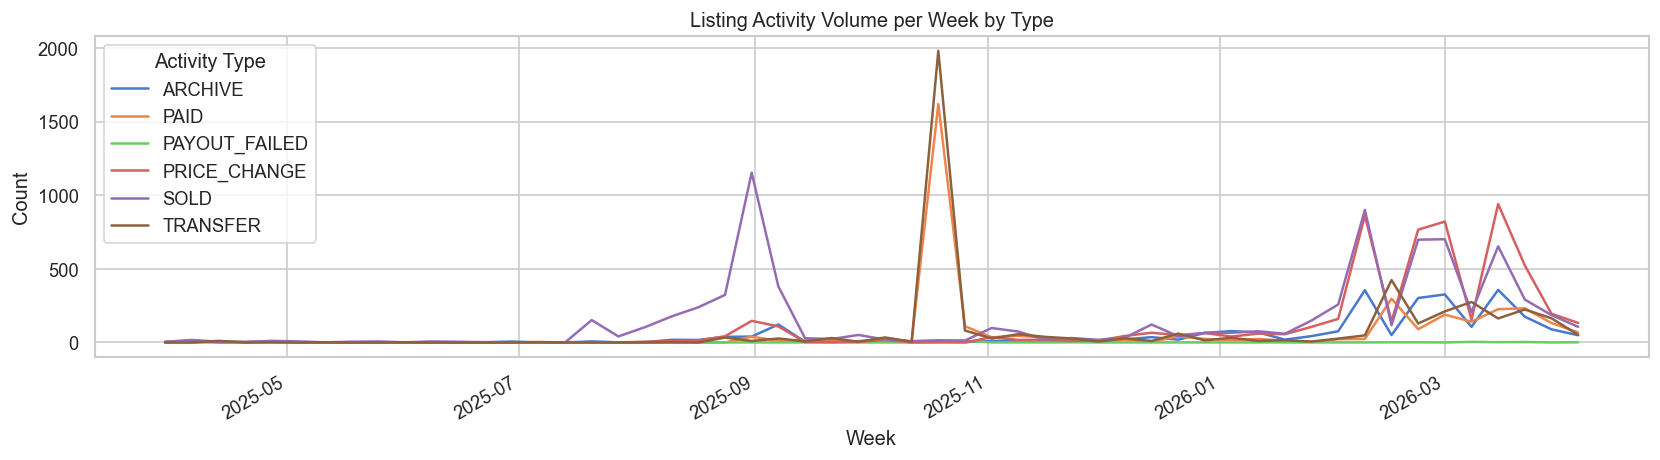

In [37]:
# Activity volume over time
activities['DATE'] = pd.to_datetime(activities['DATE'])
act_weekly = activities.groupby([pd.Grouper(key='DATE', freq='W'), 'TYPE']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 4))
act_weekly.plot(ax=ax)
ax.set_title('Listing Activity Volume per Week by Type')
ax.set_xlabel('Week')
ax.set_ylabel('Count')
ax.legend(title='Activity Type')
plt.tight_layout()
plt.show()

---
## 5. Events Analysis

In [38]:
events['START_DATE'] = pd.to_datetime(events['START_DATE'])

print('=== Event status distribution ===')
display(events['STATUS'].value_counts().rename('count').to_frame())

print(f"\nEvent date range: {events['START_DATE'].min().date()} → {events['START_DATE'].max().date()}")

=== Event status distribution ===


,count
STATUS,
PUBLISHED,612
UNPUBLISHED,5



Event date range: 2024-03-02 → 2032-08-03


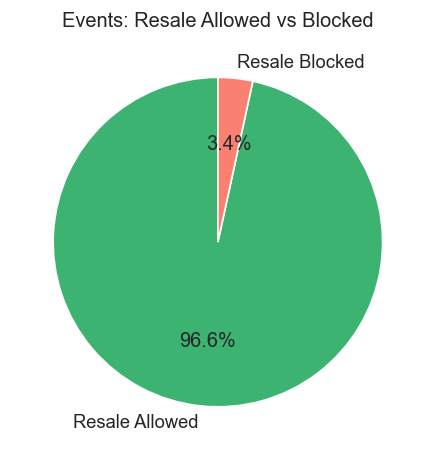

In [39]:
# Events with resale enabled vs disabled
resale_flag = events[['ID', 'NAME', 'PREVENT_LISTING_CREATION', 'RESALE_RULE_ID', 'RESALE_LOCK_TYPE']].copy()
resale_flag['resale_allowed'] = resale_flag['PREVENT_LISTING_CREATION'] != 1

fig, ax = plt.subplots(figsize=(5, 4))
resale_flag['resale_allowed'].value_counts().plot.pie(
    ax=ax,
    labels=['Resale Allowed', 'Resale Blocked'],
    autopct='%1.1f%%',
    colors=['mediumseagreen', 'salmon'],
    startangle=90
)
ax.set_ylabel('')
ax.set_title('Events: Resale Allowed vs Blocked')
plt.tight_layout()
plt.show()

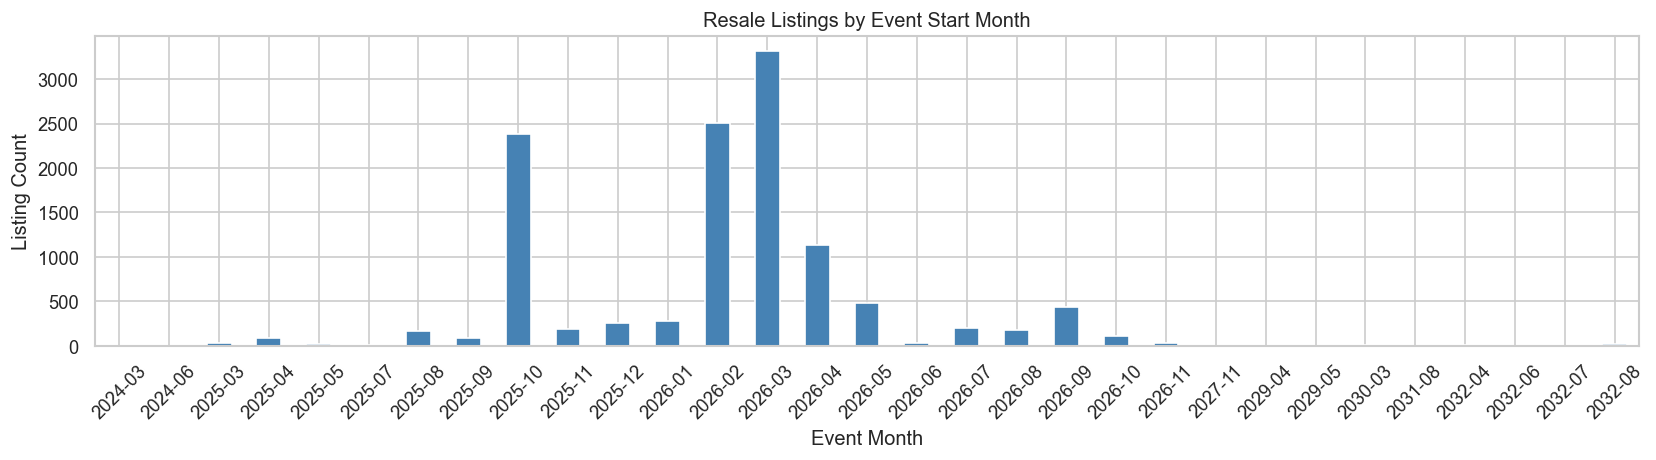

In [47]:
# Merge listings with events to get listing volume by event start month
listings_events = listings.merge(events[['ID', 'NAME', 'START_DATE']], left_on='EVENT_ID', right_on='ID', how='left')
listings_events['event_month'] = pd.to_datetime(listings_events['START_DATE']).dt.to_period('M')

monthly_event = listings_events.groupby('event_month').size().sort_index()

fig, ax = plt.subplots(figsize=(14, 4))
monthly_event.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Resale Listings by Event Start Month')
ax.set_xlabel('Event Month')
ax.set_ylabel('Listing Count')
ax.xaxis.set_tick_params(rotation=45)
plt.tight_layout()
plt.show()

---
## 6. Client Groups Analysis

In [41]:
print('=== Service level distribution ===')
display(groups['SERVICE_LEVEL'].value_counts().rename('count').to_frame())

print('\n=== Default currency ===')
display(groups['DEFAULT_CURRENCY'].value_counts().rename('count').to_frame())

=== Service level distribution ===


,count
SERVICE_LEVEL,
FLAGSHIP,39
KEY_ACCOUNTS,28
ENTERPRISE,21
SELF,16
NOT_SET,12



=== Default currency ===


,count
DEFAULT_CURRENCY,
USD,111
CAD,5


---
## 7. Summary

In [ ]:
total_gmv = sold[['PRICE']].sum().values[0]
total_tixr_fee = sold[['TIXR_FEE']].sum().values[0]
total_payout = sold[['PAYOUT_AMOUNT']].dropna().sum().values[0]

print('===== Resale Marketplace Summary =====')
print(f"Total listings created   : {len(listings):,}")
print(f"Total unique sellers     : {listings['SELLER_USER_ID'].nunique():,}")
print(f"Total events with resale : {listings['EVENT_ID'].nunique():,}")
print(f"SOLD items               : {len(sold):,}")
print(f"Listing conversion rate  : {conversion_rate:.1%}")
print(f"Total resale GMV (USD)   : ${total_gmv:,.2f}")
print(f"Total Tixr fees (USD)    : ${total_tixr_fee:,.2f}")
print(f"Total seller payouts     : ${total_payout:,.2f}")

===== Resale Marketplace Summary =====
Total listings created   : 12,018
Total unique sellers     : 7,321
Total events with resale : 617
SOLD items               : 10,950
Listing conversion rate  : 54.4%
Total resale GMV (USD)   : $1,490,180.15
Total Tixr fees (USD)    : $70,644.35
Total seller payouts     : $1,417,732.60


## San Jose Earthquakes stuff

In [53]:
sje_events = events[events['GROUP_ID'] == 2583] 

In [65]:
sje_events[['NAME', 'START_DATE']].drop_duplicates().sort_values('START_DATE')

,NAME,START_DATE
249,San Jose Earthquakes vs. Sporting Kansas City,2026-02-22 03:30:00
310,San Jose Earthquakes vs. Atlanta United FC,2026-03-01 00:30:00
333,San Jose Earthquakes vs. Seattle Sounders FC,2026-03-15 23:00:00
545,Cruz Azul vs. Atletico Nacional,2026-03-26 02:30:00
335,San Jose Earthquakes vs. San Diego FC,2026-04-05 02:30:00
338,San Jose Earthquakes vs. Austin FC,2026-04-23 02:30:00
340,San Jose Earthquakes vs. Vancouver Whitecaps FC,2026-05-10 02:30:00
342,San Jose Earthquakes vs. FC Dallas,2026-05-17 02:30:00
344,San Jose Earthquakes vs. Orlando City SC,2026-07-23 02:30:00
444,San Jose Earthquakes vs. LA Galaxy,2026-07-26 02:30:00


In [54]:
sje_listings = listings[listings['EVENT_ID'].isin(sje_events['ID'])]

In [67]:
sje_listings.head()

,ID,OPTLOCK,LISTING_ID,SELLER_USER_ID,SELLER_ORDER_ID,ORIGIN_ORDER_ID,GROUP_ID,EVENT_ID,SALE_ID,TIER_ID,CURRENCY,DELIVERY_TYPE,ADDITIONAL_DELIVERY_TYPE,ALLOW_SPLIT,DO_NOT_LEAVE_SINGLE,CREATE_DATE,LMD_DATE
3069,3071,2,d17d475a-b2b5-4344-8ff8-cf78a1616045,20434606,I3I83EWIPA,I3I83EWIPA,2583,163587,1761611,2018842,USD,ELECTRONIC,NaN,1,0,2025-12-01 20:02:59,2025-12-04 00:27:34
3070,3072,1,9ebb88da-afc6-475d-a0ec-3a25dab6c21d,20434606,I3K0CEWIP3,I3K0CEWIP3,2583,165900,1796058,2053046,USD,ELECTRONIC,NaN,1,0,2025-12-01 20:04:50,2025-12-26 06:04:41
3071,3073,2,c7ae20b0-7bf4-4183-855d-a316749ba7b7,20434606,I3K7DEWIP4,I3K7DEWIP4,2583,166153,1805643,2062549,USD,ELECTRONIC,NaN,1,0,2025-12-01 20:05:24,2025-12-27 07:02:49
3073,3075,2,42a2e8e0-cac7-4dea-bdb4-7a9165df5923,20434606,I3K7IEWIP5,I3K7IEWIP5,2583,166158,1805802,2062701,USD,ELECTRONIC,NaN,1,0,2025-12-01 20:11:27,2025-12-11 23:21:19
3075,3077,2,456533b3-8189-4551-8506-6a434d1393f9,20434606,I3K7LEWIP7,I3K7LEWIP7,2583,166161,1806287,2063154,USD,ELECTRONIC,NaN,1,0,2025-12-01 21:38:56,2026-03-12 21:12:36


In [68]:
tmp = sje_events.copy()
tmp['START_DATE'] = pd.to_datetime(tmp['START_DATE'], errors='coerce')

tmp[
    (tmp['START_DATE'].dt.month > 4) |
    ((tmp['START_DATE'].dt.month == 4) & (tmp['START_DATE'].dt.day > 15))
][['NAME', 'START_DATE']].drop_duplicates().sort_values('START_DATE')

,NAME,START_DATE
338,San Jose Earthquakes vs. Austin FC,2026-04-23 02:30:00
340,San Jose Earthquakes vs. Vancouver Whitecaps FC,2026-05-10 02:30:00
342,San Jose Earthquakes vs. FC Dallas,2026-05-17 02:30:00
344,San Jose Earthquakes vs. Orlando City SC,2026-07-23 02:30:00
444,San Jose Earthquakes vs. LA Galaxy,2026-07-26 02:30:00
346,San Jose Earthquakes vs. St. Louis City SC,2026-08-16 02:30:00
345,San Jose Earthquakes vs. Minnesota United FC,2026-08-23 02:30:00
343,San Jose Earthquakes vs. Houston Dynamo FC,2026-09-13 02:30:00
341,San Jose Earthquakes vs. Portland Timbers,2026-09-27 02:30:00
339,San Jose Earthquakes vs. Nashville SC,2026-10-18 02:30:00
